# Forest Fire Prediction Project

## Project Goal
The goal of this project is to predict the burned area of forest fires using meteorological and environmental variables.

The dataset comes from the UCI Machine Learning Repository and contains observations of forest fires in Montesinho Natural Park in Portugal.

## Target Variable
The target variable is **area**, which represents the burned forest area in hectares.

Because the distribution of this variable is highly skewed, a log transformation was applied to create **log_area**, which is used for modeling.

## Prediction Objective
This project is a **regression problem** where the goal is to predict the amount of burned forest area based on weather conditions and fire weather index variables.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
sns.set(style="whitegrid")
import os

In [41]:
# Load the dataset
df = pd.read_csv("forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


### Dataset Overview
We inspect the dataset to understand its structure, data types, and potential missing values.

In [38]:
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   X       517 non-null    int64   
 1   Y       517 non-null    int64   
 2   month   517 non-null    category
 3   day     517 non-null    category
 4   FFMC    517 non-null    float64 
 5   DMC     517 non-null    float64 
 6   DC      517 non-null    float64 
 7   ISI     517 non-null    float64 
 8   temp    517 non-null    float64 
 9   RH      517 non-null    int64   
 10  wind    517 non-null    float64 
 11  rain    517 non-null    float64 
 12  area    517 non-null    float64 
dtypes: category(2), float64(8), int64(3)
memory usage: 46.3 KB


np.int64(4)

## Initial Cleaning

The dataset was inspected for missing values, duplicates, and incorrect data types.

- No missing values were found.
- The dataset contains no duplicate rows.
- The variables `month` and `day` are categorical features representing time information.

In [37]:
df['month'] = df['month'].astype('category')
df['day'] = df['day'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   X       517 non-null    int64   
 1   Y       517 non-null    int64   
 2   month   517 non-null    category
 3   day     517 non-null    category
 4   FFMC    517 non-null    float64 
 5   DMC     517 non-null    float64 
 6   DC      517 non-null    float64 
 7   ISI     517 non-null    float64 
 8   temp    517 non-null    float64 
 9   RH      517 non-null    int64   
 10  wind    517 non-null    float64 
 11  rain    517 non-null    float64 
 12  area    517 non-null    float64 
dtypes: category(2), float64(8), int64(3)
memory usage: 46.3 KB


- Visualize the distribution of burned area.
- The target variable is highly right-skewed, justifying log transformation.

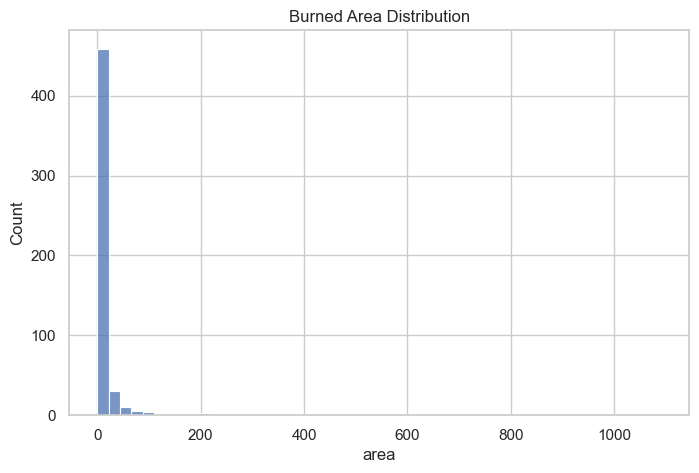

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['area'], bins=50)
plt.title("Burned Area Distribution")
plt.show()

The burned area variable is highly right-skewed, meaning most fires burn very small areas while a few fires burn extremely large areas.

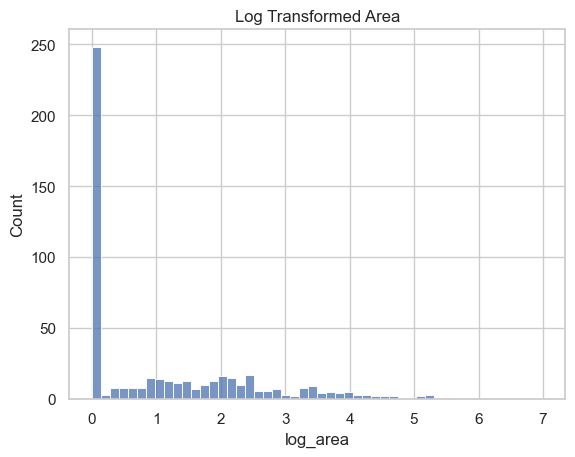

In [23]:
df['log_area'] = np.log1p(df['area'])

sns.histplot(df['log_area'], bins=50)
plt.title("Log Transformed Area")
plt.show()

We visualize distributions of all numeric features to understand ranges, skewness, and potential outliers.

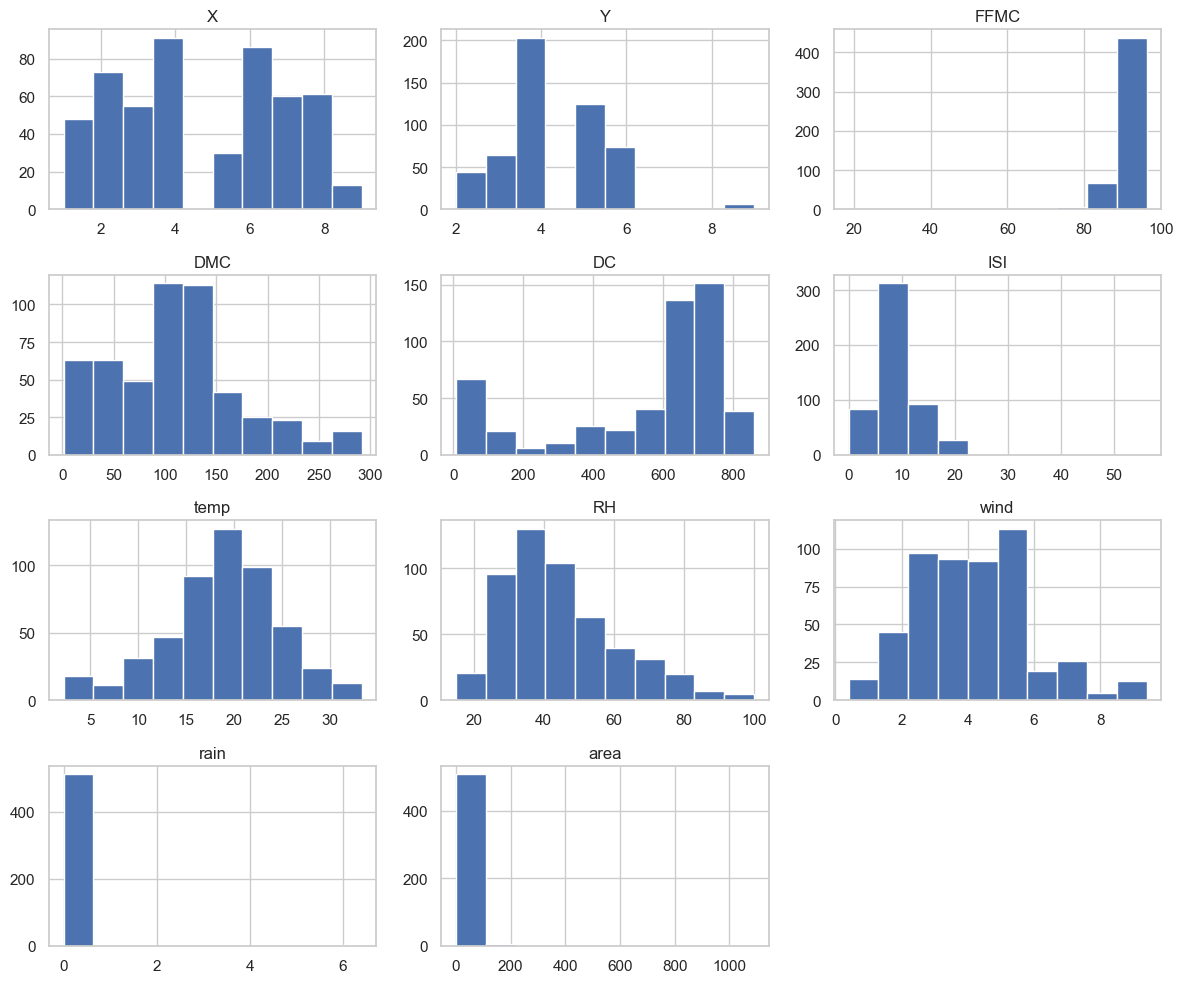

In [45]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

- Explore correlations between numeric features and the target.
- Check for potential multicollinearity.

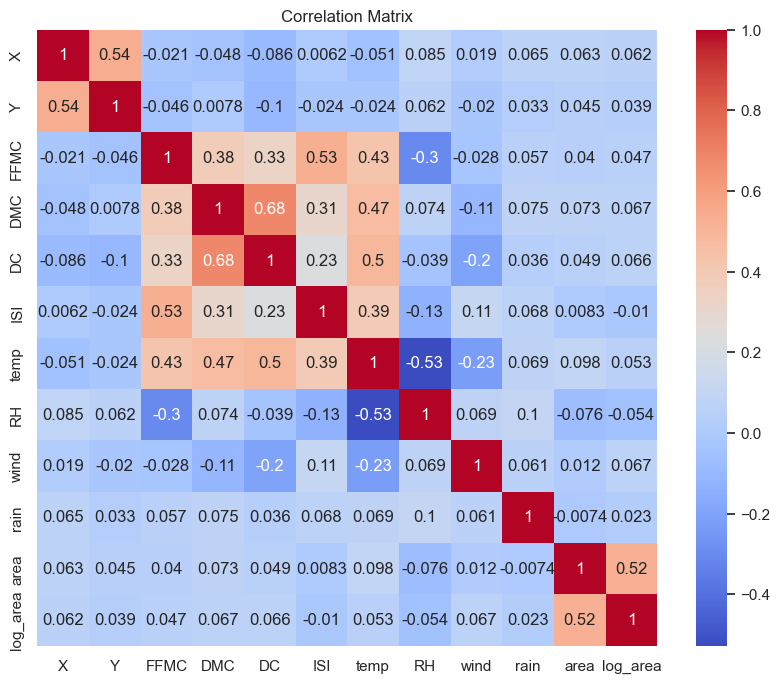

In [24]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

Some fire weather indices (DMC, DC, and FFMC) show moderate correlation with each other, which may indicate multicollinearity.
However, most features show weak correlation with the target variable.

- Visualize number of fires by month and day.
- Identify trends in the data.

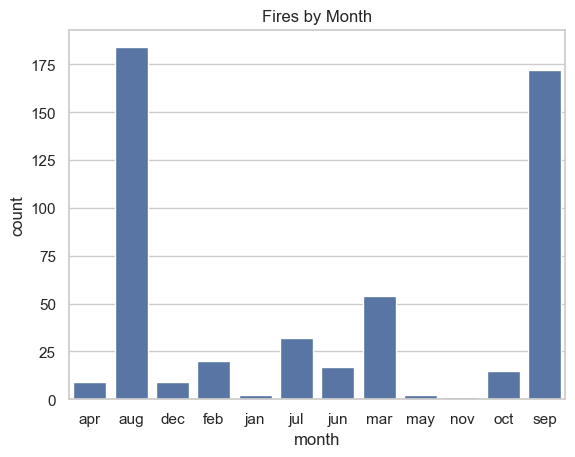

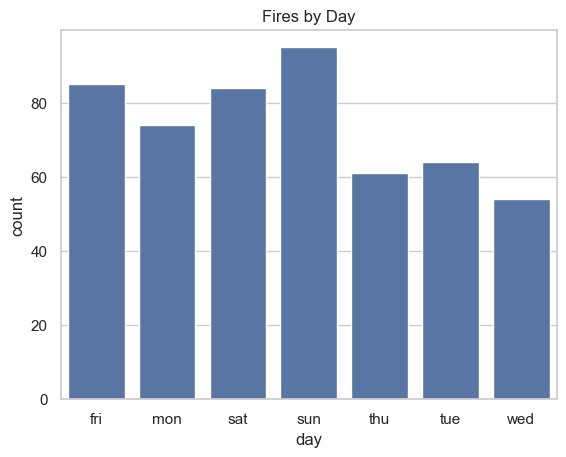

In [34]:
sns.countplot(x='month', data=df)
plt.title("Fires by Month")
plt.show()

sns.countplot(x='day', data=df)
plt.title("Fires by Day")
plt.show()

- Boxplot to detect extreme values in burned area.
- Log transformation helps reduce skewness.

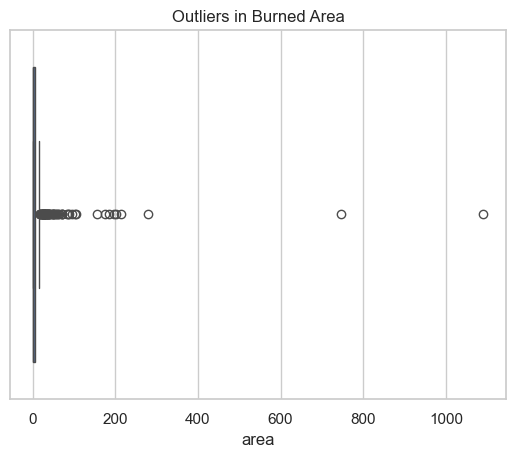

Skewness of area: 12.846933533934868


In [47]:
sns.boxplot(x=df['area'])
plt.title("Outliers in Burned Area")
plt.show()

print("Skewness of area:", df['area'].skew())

The target variable shows strong skewness, which is why a log transformation is applied during preprocessing.

- Examine relationships between key numeric features and burned area.
- Scatterplots help identify potential predictive variables.

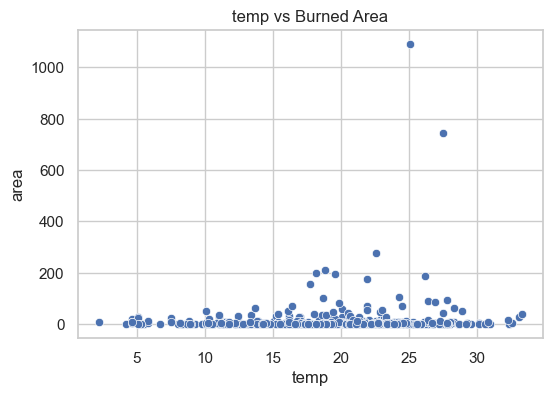

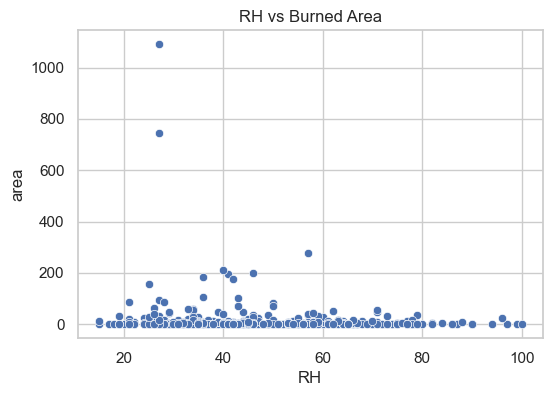

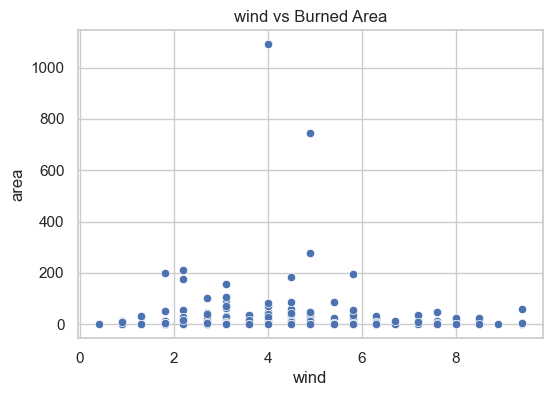

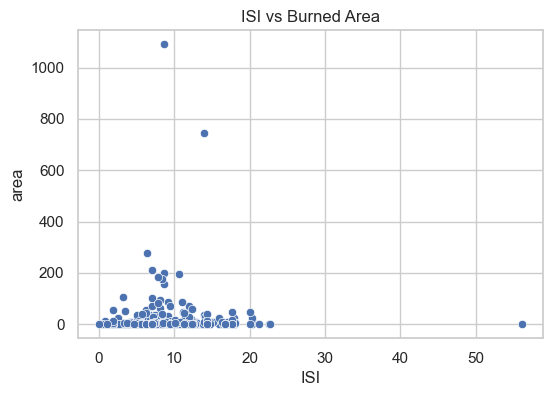

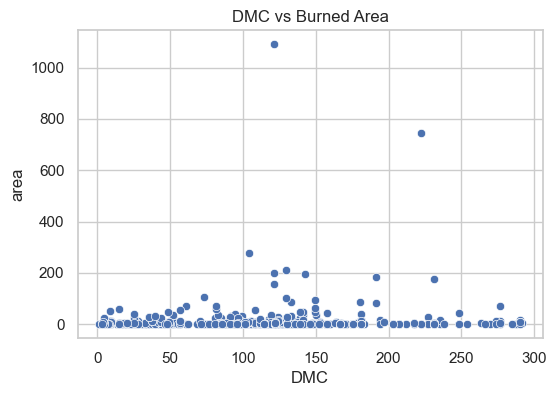

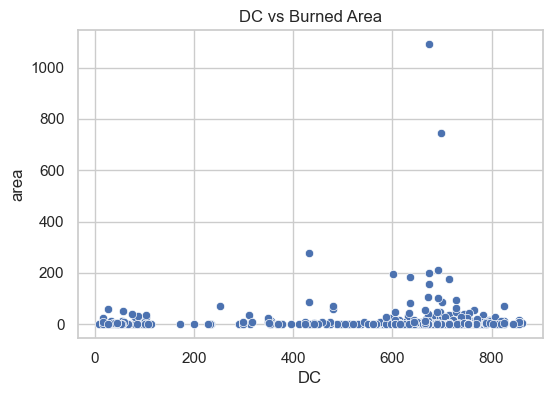

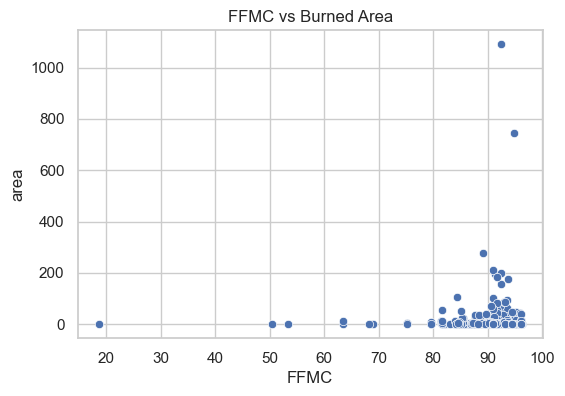

In [48]:
features = ['temp', 'RH', 'wind', 'ISI', 'DMC', 'DC', 'FFMC']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=feature, y='area', data=df)
    plt.title(f'{feature} vs Burned Area')
    plt.show()

Weather variables such as temperature, humidity, and wind speed may influence fire size.

### Key Insights from EDA

- Dataset contains 517 observations and 13 features.
- No missing values or duplicates were found.
- Target variable 'area' is highly right-skewed; log transformation applied to create 'log_area'.
- Numeric features show weak correlation with target; some fire weather indices (DMC, DC, FFMC) show moderate correlation among themselves (multicollinearity risk).
- Outliers exist in burned area, justifying the log transformation.
- Categorical features (month, day) are imbalanced but usable.
- Scatterplots indicate temperature, humidity, wind, ISI, and fire weather indices could influence fire size.